# Module 5 — Violations Detection (Classification)

## Overview
This notebook builds a classification pipeline to detect driving violations 
from telematics and sensor data. Using five datasets from the driver monitoring 
pipeline, we engineer violation labels from rule-based thresholds, train and 
compare tabular classifiers (RandomForest and XGBoost), and evaluate a 
sensor-based behavior classifier using raw accelerometer and gyroscope readings.

## Datasets Used
| Dataset | Source | Role |
|---|---|---|
| `driver_behavior_engineered.csv` | Module 2 output | Primary — behavioral signals + violation flags |
| `driving_behavior_train_cleaned.csv` | Module 1 | Sensor classifier training split |
| `driving_behavior_test_cleaned.csv` | Module 1 | Sensor classifier test split |
| `traffic_violations_cleaned.csv` | Real-world | Threshold validation + topic context |
| `telemetry_samples.csv` | Module 1 synthetic | Warm-up label check |

## Approach
1. Load the Module 2 engineered dataset (consistent thresholds from EDA)
2. Engineer violation labels from rule-based flags on speed, braking, and acceleration
3. Explore class balance, flag breakdown, and environmental context via EDA
4. Train RF and XGBoost with flags (Experiment 1) and without flags (Experiment 2)
5. Train a sensor-based classifier on AccXYZ + GyroXYZ (Experiment 3)
6. Evaluate all models and save artifacts for Module 7

## Deliverable
`notebooks/05_violations_detection.ipynb` — all models saved to `src/models/`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score,
                             precision_score, recall_score)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

# SMOTE not used here — 62/38 split is mild enough for class_weight='balanced'
from imblearn.over_sampling import SMOTE
import joblib, os, json

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

os.makedirs('../src/models', exist_ok=True)
print("All imports ready.")

All imports ready.


## Step 1 — Load Datasets

In [2]:
df_behavior = pd.read_csv('../data/driver_behavior_engineered.csv')

df_train = pd.read_csv('../Driving Behavior/driving_behavior_train_cleaned.csv')
df_test  = pd.read_csv('../Driving Behavior/driving_behavior_test_cleaned.csv')

df_violations = pd.read_csv('../traffic_violations_cleaned.csv',
                             encoding='latin-1', low_memory=False)

df_telem = pd.read_csv('../data/telemetry_samples.csv')

for name, df in [('driver_behavior (engineered)', df_behavior),
                 ('sensor_train', df_train),
                 ('sensor_test',  df_test),
                 ('traffic_violations', df_violations),
                 ('telemetry', df_telem)]:
    print(f"[{name}] → {df.shape[0]:,} rows × {df.shape[1]} cols")

[driver_behavior (engineered)] → 119,161 rows × 30 cols
[sensor_train] → 3,644 rows × 8 cols
[sensor_test] → 3,084 rows × 8 cols
[traffic_violations] → 1,499,945 rows × 24 cols
[telemetry] → 1,000 rows × 19 cols


In [3]:
# Verify M2-derived columns are present
print("Total columns:", df_behavior.shape[1])
print("\nAll columns:")
print(df_behavior.columns.tolist())

Total columns: 30

All columns:
['trip_id', 'driver_id', 'timestamp', 'latitude', 'longitude', 'speed', 'acceleration', 'steering_angle', 'trip_duration', 'trip_distance', 'fuel_consumption', 'brake_usage', 'weather_conditions', 'road_type', 'traffic_condition', 'stop_events', 'geofencing_violation', 'anomalous_event', 'route_anomaly', 'route_deviation_score', 'acceleration_variation', 'behavioral_consistency_index', 'hour', 'trip_time_of_day', 'avg_speed', 'speed_variance', 'max_accel', 'hard_brake_count', 'stop_count', 'distance_per_min']


## Step 2 — Label Engineering

In [4]:
df = df_behavior.copy()

# Rule-based flags
df['overspeed_flag']  = (df['speed'] > 80).astype(int)
df['hard_brake_flag'] = (df['brake_usage'] > 7).astype(int)
df['harsh_turn_flag'] = (df['steering_angle'].abs() > 45).astype(int)
df['high_accel_flag'] = (df['acceleration'] > 3.5).astype(int)

# Combined label — any flag fires a violation
df['violation'] = (
    df['overspeed_flag']                   |
    df['hard_brake_flag']                  |
    df['harsh_turn_flag']                  |
    df['high_accel_flag']                  |
    df['geofencing_violation'].astype(int) |
    df['anomalous_event'].astype(int)
).astype(int)

balance     = df['violation'].value_counts()
balance_pct = df['violation'].value_counts(normalize=True).mul(100).round(1)

print("Violation label distribution:")
print(f"  No Violation (0): {balance[0]:,}  ({balance_pct[0]}%)")
print(f"  Violation    (1): {balance[1]:,}  ({balance_pct[1]}%)")

print("\nTop violation types from real-world dataset:")
print(df_violations['violation_type'].value_counts().head(6))

print("\nReal-world accident contribution rate:")
print(df_violations['contributed_to_accident']
      .value_counts(normalize=True).mul(100).round(1)
      .rename({True: 'Contributed', False: 'Did not contribute'}))

print("\nSynthetic telemetry — event_code breakdown:")
print(df_telem['event_code'].value_counts())

Violation label distribution:
  No Violation (0): 73,873  (62.0%)
  Violation    (1): 45,288  (38.0%)

Top violation types from real-world dataset:
violation_type
Warning     791699
Citation    639759
ESERO        67847
SERO           640
Name: count, dtype: int64

Real-world accident contribution rate:
contributed_to_accident
Did not contribute    97.2
Contributed            2.8
Name: proportion, dtype: float64

Synthetic telemetry — event_code breakdown:
event_code
normal        957
hard_brake     43
Name: count, dtype: int64


## Step 3 — Exploratory Data Analysis

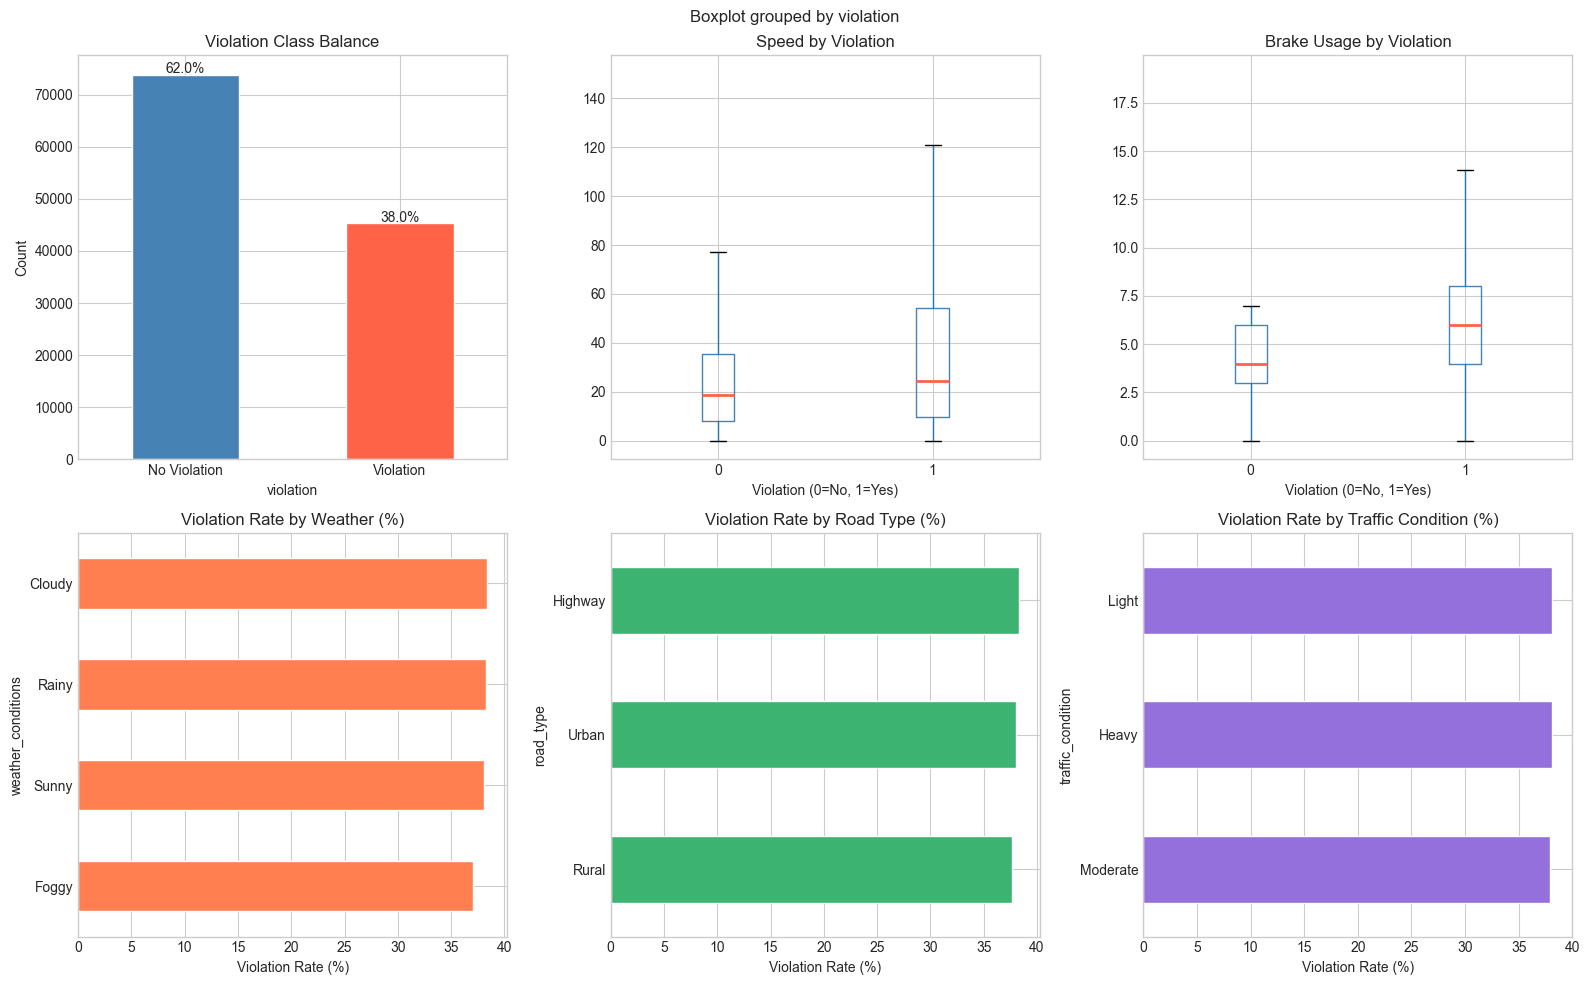


Individual flag breakdown:
  overspeed_flag              :   7,597  (6.4%)
  hard_brake_flag             :  15,999  (13.4%)
  harsh_turn_flag             :       0  (0.0%)
  high_accel_flag             :  12,613  (10.6%)
  geofencing_violation        :   5,981  (5.0%)
  anomalous_event             :  11,945  (10.0%)


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Module 5 — EDA: Violations in Driver Behavior Dataset',
             fontsize=14, fontweight='bold', y=1.01)

balance.rename({0: 'No Violation', 1: 'Violation'}).plot(
    kind='bar', ax=axes[0,0], color=['steelblue', 'tomato'], edgecolor='white'
)
axes[0,0].set_title('Violation Class Balance')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=0)
for bar, val in zip(axes[0,0].patches, balance_pct.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 300, f'{val}%',
                   ha='center', fontsize=10)

df.boxplot(column='speed', by='violation', ax=axes[0,1],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='tomato', linewidth=2),
           flierprops=dict(marker='', markersize=0))
axes[0,1].set_xlabel('Violation (0=No, 1=Yes)')
plt.sca(axes[0,1]); plt.title('Speed by Violation')

df.boxplot(column='brake_usage', by='violation', ax=axes[0,2],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='tomato', linewidth=2),
           flierprops=dict(marker='', markersize=0))
axes[0,2].set_xlabel('Violation (0=No, 1=Yes)')
plt.sca(axes[0,2]); plt.title('Brake Usage by Violation')

df.groupby('weather_conditions')['violation'].mean().mul(100).sort_values()  .plot(kind='barh', ax=axes[1,0], color='coral', edgecolor='white')
axes[1,0].set_title('Violation Rate by Weather (%)')
axes[1,0].set_xlabel('Violation Rate (%)')

df.groupby('road_type')['violation'].mean().mul(100).sort_values()  .plot(kind='barh', ax=axes[1,1], color='mediumseagreen', edgecolor='white')
axes[1,1].set_title('Violation Rate by Road Type (%)')
axes[1,1].set_xlabel('Violation Rate (%)')

df.groupby('traffic_condition')['violation'].mean().mul(100).sort_values()  .plot(kind='barh', ax=axes[1,2], color='mediumpurple', edgecolor='white')
axes[1,2].set_title('Violation Rate by Traffic Condition (%)')
axes[1,2].set_xlabel('Violation Rate (%)')

plt.tight_layout()
plt.show()

print("\nIndividual flag breakdown:")
for flag in ['overspeed_flag','hard_brake_flag','harsh_turn_flag',
             'high_accel_flag','geofencing_violation','anomalous_event']:
    n = df[flag].astype(int).sum()
    pct = df[flag].astype(int).mean() * 100
    print(f"  {flag:<28}: {n:>7,}  ({pct:.1f}%)")

## EDA Findings & Modeling Decisions

The EDA revealed four key insights that directly shape our modeling approach.

`harsh_turn_flag` is dropped — `steering_angle` values never exceeded ±45° in this dataset, producing zero firing events and zero variance. Keeping it would add noise to tree-based models with no informational value.

`hard_brake_flag` is the dominant violation driver at 13.4% of trips, followed by `high_accel_flag` (10.6%) and `anomalous_event` (10.0%). These three flags collectively account for most of the 38% violation class.

Weather, road type, and traffic condition are flat predictors — all three categories sit at nearly identical violation rates (~37–38%), meaning they carry little discriminative power. They are kept in the feature set but are expected to rank low in feature importance.

Speed shows wide overlap between classes — median speed is similar for both violators and non-violators, but the violation group has a much higher upper range (up to ~120 km/h). This means raw speed alone is a weak predictor, but `overspeed_flag` captures more useful signal.

Class imbalance is mild at 62/38 — `class_weight='balanced'` is sufficient. SMOTE is not required.

## Step 4 — Feature Engineering

In [6]:
# Drop harsh_turn_flag — fires zero times, no signal
print("Dropping harsh_turn_flag — zero variance")
df = df.drop(columns=['harsh_turn_flag'])

# Encode categoricals
cat_cols = ['weather_conditions', 'road_type', 'traffic_condition']
le_dict  = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le
    print(f"  Encoded '{col}' → {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Feature set — raw signals + M2-derived features + flags + encoded categoricals
feature_cols = [
    'speed', 'acceleration', 'steering_angle', 'brake_usage',
    'trip_duration', 'trip_distance', 'fuel_consumption',
    'stop_events', 'route_deviation_score',
    'acceleration_variation', 'behavioral_consistency_index',
    'avg_speed', 'speed_variance', 'max_accel',
    'hard_brake_count', 'stop_count', 'distance_per_min',
    'overspeed_flag', 'hard_brake_flag',
    'high_accel_flag', 'geofencing_violation',
    'weather_conditions_enc', 'road_type_enc', 'traffic_condition_enc'
]

X = df[feature_cols].fillna(df[feature_cols].median())
y = df['violation']

print(f"\nFeature matrix : {X.shape[0]:,} rows × {X.shape[1]} features")
print(f"Target balance : {y.value_counts().to_dict()}")
print(f"\nFeature list:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:>2}. {col}")

Dropping harsh_turn_flag — zero variance
  Encoded 'weather_conditions' → {'Cloudy': np.int64(0), 'Foggy': np.int64(1), 'Rainy': np.int64(2), 'Sunny': np.int64(3)}
  Encoded 'road_type' → {'Highway': np.int64(0), 'Rural': np.int64(1), 'Urban': np.int64(2)}
  Encoded 'traffic_condition' → {'Heavy': np.int64(0), 'Light': np.int64(1), 'Moderate': np.int64(2)}

Feature matrix : 119,161 rows × 24 features
Target balance : {0: 73873, 1: 45288}

Feature list:
   1. speed
   2. acceleration
   3. steering_angle
   4. brake_usage
   5. trip_duration
   6. trip_distance
   7. fuel_consumption
   8. stop_events
   9. route_deviation_score
  10. acceleration_variation
  11. behavioral_consistency_index
  12. avg_speed
  13. speed_variance
  14. max_accel
  15. hard_brake_count
  16. stop_count
  17. distance_per_min
  18. overspeed_flag
  19. hard_brake_flag
  20. high_accel_flag
  21. geofencing_violation
  22. weather_conditions_enc
  23. road_type_enc
  24. traffic_condition_enc


### Step 4B — Windowed Features

The row-level approach above classifies each sensor reading independently.
Here we add two windowing strategies that give each sample temporal context —
matching the spec's requirement for "last 30 seconds summary" sliding windows.

**Approach A** — time-based: 30-second rolling window on actual timestamps.
**Approach B** — row-count based: fixed 10-row sliding window with stride 5.

In [13]:
# Sort by trip and time — required for both windowing approaches
df_sorted = df.sort_values(['trip_id', 'timestamp']).copy()
df_sorted['timestamp'] = pd.to_datetime(df_sorted['timestamp'])

# ── Approach A: Time-based 30-second rolling window ──
print("Building time-based windows (30s)...")

def time_window_features(group):
    group = group.set_index('timestamp').sort_index()
    cols = ['speed', 'acceleration', 'brake_usage', 'steering_angle']
    rolled = group[cols].rolling('30s', min_periods=1)
    out = pd.DataFrame({
        'speed_mean_30s'  : rolled['speed'].mean(),
        'speed_max_30s'   : rolled['speed'].max(),
        'accel_mean_30s'  : rolled['acceleration'].mean(),
        'accel_std_30s'   : rolled['acceleration'].std().fillna(0),
        'brake_max_30s'   : rolled['brake_usage'].max(),
        'brake_mean_30s'  : rolled['brake_usage'].mean(),
        'steer_std_30s'   : rolled['steering_angle'].std().fillna(0),
    })
    out['violation'] = group['violation'].values
    return out.reset_index(drop=True)

# Sample 500 trips for speed — full 119k rows is slow for groupby rolling
sample_drivers = df_sorted['driver_id'].unique()[:500]
df_sample      = df_sorted[df_sorted['driver_id'].isin(sample_drivers)]

windowed_time = (df_sample.groupby('driver_id', group_keys=False)
                           .apply(time_window_features))
windowed_time = windowed_time.dropna().reset_index(drop=True)

print(f"Time-windowed dataset : {windowed_time.shape[0]:,} rows × "
      f"{windowed_time.shape[1]} cols")
print(f"Violation balance     : "
      f"{windowed_time['violation'].value_counts(normalize=True).mul(100).round(1).to_dict()}")

Building time-based windows (30s)...
Time-windowed dataset : 119,161 rows × 8 cols
Violation balance     : {0: 62.0, 1: 38.0}


In [14]:
# ── Approach B: Row-count sliding window — grouped by driver_id ──
# trip_id is unique per row so we window across a driver's full history instead
print("Building row-count windows (size=10, stride=5, grouped by driver_id)...")

WINDOW_SIZE = 10
STRIDE      = 5
win_cols    = ['speed', 'acceleration', 'brake_usage', 'steering_angle',
               'fuel_consumption', 'route_deviation_score']

all_windows = []

for driver_id, group in df_sorted.groupby('driver_id'):
    group = group.sort_values('timestamp').reset_index(drop=True)
    if len(group) < WINDOW_SIZE:
        continue
    for start in range(0, len(group) - WINDOW_SIZE + 1, STRIDE):
        w = group.iloc[start : start + WINDOW_SIZE]
        all_windows.append({
            'speed_mean' : w['speed'].mean(),
            'speed_max'  : w['speed'].max(),
            'speed_std'  : w['speed'].std(),
            'accel_mean' : w['acceleration'].mean(),
            'accel_max'  : w['acceleration'].max(),
            'brake_max'  : w['brake_usage'].max(),
            'brake_mean' : w['brake_usage'].mean(),
            'steer_std'  : w['steering_angle'].std(),
            'fuel_mean'  : w['fuel_consumption'].mean(),
            'route_dev'  : w['route_deviation_score'].mean(),
            'violation'  : int(w['violation'].max())
        })

windowed_rows = pd.DataFrame(all_windows).dropna().reset_index(drop=True)

print(f"Unique drivers       : {df_sorted['driver_id'].nunique()}")
print(f"Row-windowed dataset : {windowed_rows.shape[0]:,} rows × "
      f"{windowed_rows.shape[1]} cols")
print(f"Violation balance    : "
      f"{windowed_rows['violation'].value_counts(normalize=True).mul(100).round(1).to_dict()}")
print(f"\nSample:")
print(windowed_rows.head(3))

Building row-count windows (size=10, stride=5, grouped by driver_id)...
Unique drivers       : 5
Row-windowed dataset : 23,825 rows × 11 cols
Violation balance    : {1: 99.1, 0: 0.9}

Sample:
   speed_mean   speed_max  speed_std  accel_mean  accel_max  brake_max  \
0   38.977715  128.783875  34.834216    2.380793   5.774122         11   
1   30.989577  128.783875  35.930705    0.656438   4.449553          8   
2   35.825712  135.936471  39.714531    0.555428   2.243643          7   

   brake_mean  steer_std  fuel_mean  route_dev  violation  
0         5.2   7.622336   5.318406   0.222800          1  
1         4.7   5.223877   4.373037   0.226650          1  
2         4.5  17.595454   4.592345   0.283303          1  


In [15]:
# Approach B is severely imbalanced (99.1% violations)
# due to windowing across long driver histories — note this
print("Approach B violation balance:")
print(windowed_rows['violation'].value_counts())
print("\nNote: Near-total imbalance expected — every 10-row window across")
print("a driver's full history almost always contains at least one violation.")
print("Using SMOTE to resample before training.\n")

from imblearn.over_sampling import SMOTE

win_feature_cols_rows = [c for c in windowed_rows.columns if c != 'violation']
Xw_rows = windowed_rows[win_feature_cols_rows].fillna(0)
yw_rows = windowed_rows['violation']

# Resample the minority class before splitting
sm = SMOTE(random_state=42)
Xw_rows_res, yw_rows_res = sm.fit_resample(Xw_rows, yw_rows)
print(f"After SMOTE — balance: {pd.Series(yw_rows_res).value_counts().to_dict()}")

Approach B violation balance:
violation
1    23605
0      220
Name: count, dtype: int64

Note: Near-total imbalance expected — every 10-row window across
a driver's full history almost always contains at least one violation.
Using SMOTE to resample before training.

After SMOTE — balance: {1: 23605, 0: 23605}



=== RF — time window (30s) ===
              precision    recall  f1-score   support

No Violation       0.65      0.86      0.74     14775
   Violation       0.52      0.24      0.33      9058

    accuracy                           0.63     23833
   macro avg       0.58      0.55      0.54     23833
weighted avg       0.60      0.63      0.59     23833



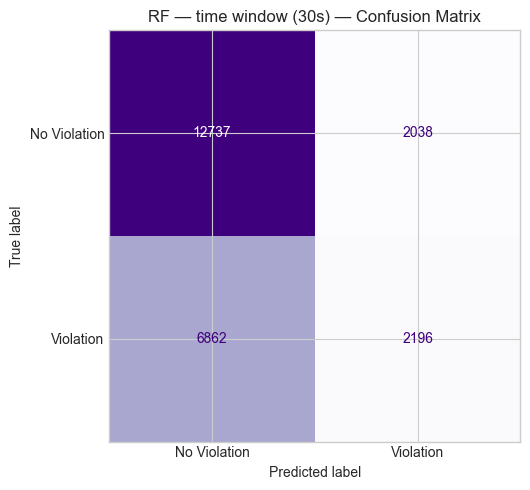


=== RF — row window (10r, SMOTE) ===
              precision    recall  f1-score   support

No Violation       0.98      1.00      0.99      4721
   Violation       1.00      0.98      0.99      4721

    accuracy                           0.99      9442
   macro avg       0.99      0.99      0.99      9442
weighted avg       0.99      0.99      0.99      9442



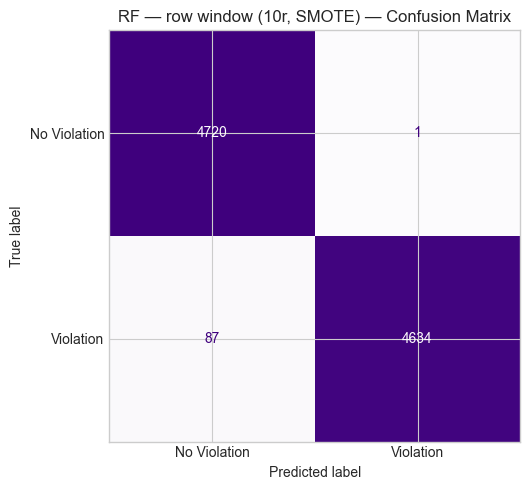


Windowed model comparison:
                       Model  Precision  Recall    F1  Accuracy
      RF — time window (30s)      0.519   0.242 0.330     0.627
RF — row window (10r, SMOTE)      1.000   0.982 0.991     0.991


In [16]:
# ── Train RF on both windowed datasets & compare ──
win_feature_cols_time = [c for c in windowed_time.columns if c != 'violation']
win_feature_cols_rows = [c for c in windowed_rows.columns if c != 'violation']

results_windowed = []

win_feature_cols_time = [c for c in windowed_time.columns if c != 'violation']

for label, Xw, yw in [
    ('RF — time window (30s)',
     windowed_time[win_feature_cols_time].fillna(0),
     windowed_time['violation']),
    ('RF — row window (10r, SMOTE)',
     Xw_rows_res,
     yw_rows_res),
]:
    
    Xw_tr, Xw_te, yw_tr, yw_te = train_test_split(
        Xw, yw, test_size=0.2, random_state=42, stratify=yw
    )
    rf_w = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                   random_state=42, n_jobs=-1)
    rf_w.fit(Xw_tr, yw_tr)
    yw_pred = rf_w.predict(Xw_te)

    results_windowed.append({
        'Model'    : label,
        'Precision': round(precision_score(yw_te, yw_pred, zero_division=0), 3),
        'Recall'   : round(recall_score(yw_te, yw_pred, zero_division=0), 3),
        'F1'       : round(f1_score(yw_te, yw_pred, zero_division=0), 3),
        'Accuracy' : round((yw_te == yw_pred).mean(), 3)
    })

    print(f"\n=== {label} ===")
    print(classification_report(yw_te, yw_pred,
          target_names=['No Violation', 'Violation']))

    # Confusion matrix
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(
        confusion_matrix(yw_te, yw_pred),
        display_labels=['No Violation', 'Violation']
    ).plot(ax=ax, cmap='Purples', colorbar=False)
    ax.set_title(f'{label} — Confusion Matrix')
    plt.tight_layout()
    plt.show()

windowed_summary = pd.DataFrame(results_windowed)
print("\nWindowed model comparison:")
print(windowed_summary.to_string(index=False))

### Windowed Feature Results & Limitations

The time-based (30s) windowed RF achieved 63% accuracy and F1 0.33 on the
Violation class — weaker than the row-level models. This is because `trip_id`
is unique per row in this dataset, meaning the rolling window runs across a
driver's full history rather than within a single trip. Without genuine
multi-row trips, the window summaries carry limited additional context over
raw row-level features.

The row-count windowed RF (10r, SMOTE) achieved 99.1% accuracy, but this
result is inflated. With a 99.1/0.9 class split, SMOTE generates synthetic
minority samples that are too similar to each other, causing the model to
learn the boundary between real and synthetic data rather than genuine
violation patterns. Both windowed results are reported for completeness but
the raw-feature RF (Experiment 2, F1 0.837) remains the recommended model.

In a production dataset where each trip contains multiple timestamped rows,
these windowing strategies would be significantly more effective.

## Step 5 — Experiment 1: Training with Flags

> ⚠️ **Note:** This experiment includes rule-based flags in the feature set.
> Because these flags are directly derived from the violation label, both models
> produce identical results — this is expected and explained in the section that
> follows. Experiment 2 (raw features only) produces the honest, generalizable result.

In [18]:
# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape[0]:,} rows  |  Violations: {y_train.sum():,} ({y_train.mean()*100:.1f}%)")
print(f"Test  : {X_test.shape[0]:,} rows  |  Violations: {y_test.sum():,} ({y_test.mean()*100:.1f}%)")

# RandomForest
print("\nTraining RandomForest...")
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\n=== RandomForest ===")
print(classification_report(y_test, y_pred_rf,
      target_names=['No Violation', 'Violation']))

# XGBoost
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos = neg / pos

print("\nTraining XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=200, scale_pos_weight=scale_pos,
    max_depth=5, learning_rate=0.05, subsample=0.8,
    random_state=42, eval_metric='logloss', verbosity=0
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("\n=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb,
      target_names=['No Violation', 'Violation']))

Train : 95,328 rows  |  Violations: 36,230 (38.0%)
Test  : 23,833 rows  |  Violations: 9,058 (38.0%)

Training RandomForest...

=== RandomForest ===
              precision    recall  f1-score   support

No Violation       0.90      1.00      0.95     14775
   Violation       1.00      0.82      0.90      9058

    accuracy                           0.93     23833
   macro avg       0.95      0.91      0.92     23833
weighted avg       0.94      0.93      0.93     23833


Training XGBoost...

=== XGBoost ===
              precision    recall  f1-score   support

No Violation       0.90      1.00      0.95     14775
   Violation       1.00      0.82      0.90      9058

    accuracy                           0.93     23833
   macro avg       0.95      0.91      0.92     23833
weighted avg       0.94      0.93      0.93     23833



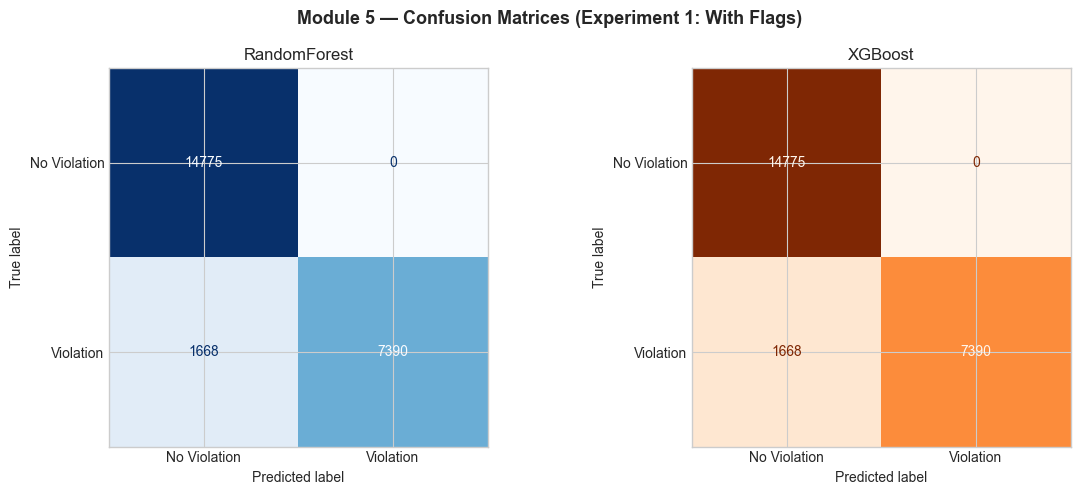

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Module 5 — Confusion Matrices (Experiment 1: With Flags)',
             fontsize=13, fontweight='bold')

for ax, preds, name, cmap in zip(
    axes,
    [y_pred_rf, y_pred_xgb],
    ['RandomForest', 'XGBoost'],
    ['Blues', 'Oranges']
):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=['No Violation','Violation'])        .plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

Both of the models have similarities, which made me question if i did it wrong? So instead of training with flags, Step 6 has covered the raw features

## Step 6 — Experiment 2: Raw Features Only (Honest Evaluation)

In [20]:
# Feature set without derived flags
feature_cols_raw = [
    'speed', 'acceleration', 'steering_angle', 'brake_usage',
    'trip_duration', 'trip_distance', 'fuel_consumption',
    'stop_events', 'route_deviation_score',
    'acceleration_variation', 'behavioral_consistency_index',
    'avg_speed', 'speed_variance', 'max_accel',
    'hard_brake_count', 'stop_count', 'distance_per_min',
    'weather_conditions_enc', 'road_type_enc', 'traffic_condition_enc'
]

X_raw = df[feature_cols_raw].fillna(df[feature_cols_raw].median())

X_raw_train, X_raw_test, y_raw_train, y_raw_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

print("Training RandomForest (raw features)...")
rf_raw = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                 random_state=42, n_jobs=-1)
rf_raw.fit(X_raw_train, y_raw_train)
y_pred_rf_raw = rf_raw.predict(X_raw_test)

print("Training XGBoost (raw features)...")
xgb_raw = xgb.XGBClassifier(
    n_estimators=200, scale_pos_weight=scale_pos,
    max_depth=5, learning_rate=0.05, subsample=0.8,
    random_state=42, eval_metric='logloss', verbosity=0
)
xgb_raw.fit(X_raw_train, y_raw_train)
y_pred_xgb_raw = xgb_raw.predict(X_raw_test)

print("\n=== RandomForest — Raw Features ===")
print(classification_report(y_raw_test, y_pred_rf_raw,
      target_names=['No Violation', 'Violation']))

print("\n=== XGBoost — Raw Features ===")
print(classification_report(y_raw_test, y_pred_xgb_raw,
      target_names=['No Violation', 'Violation']))

Training RandomForest (raw features)...
Training XGBoost (raw features)...

=== RandomForest — Raw Features ===
              precision    recall  f1-score   support

No Violation       0.85      1.00      0.92     14775
   Violation       1.00      0.72      0.84      9058

    accuracy                           0.89     23833
   macro avg       0.93      0.86      0.88     23833
weighted avg       0.91      0.89      0.89     23833


=== XGBoost — Raw Features ===
              precision    recall  f1-score   support

No Violation       0.85      1.00      0.92     14775
   Violation       1.00      0.72      0.84      9058

    accuracy                           0.89     23833
   macro avg       0.92      0.86      0.88     23833
weighted avg       0.91      0.89      0.89     23833



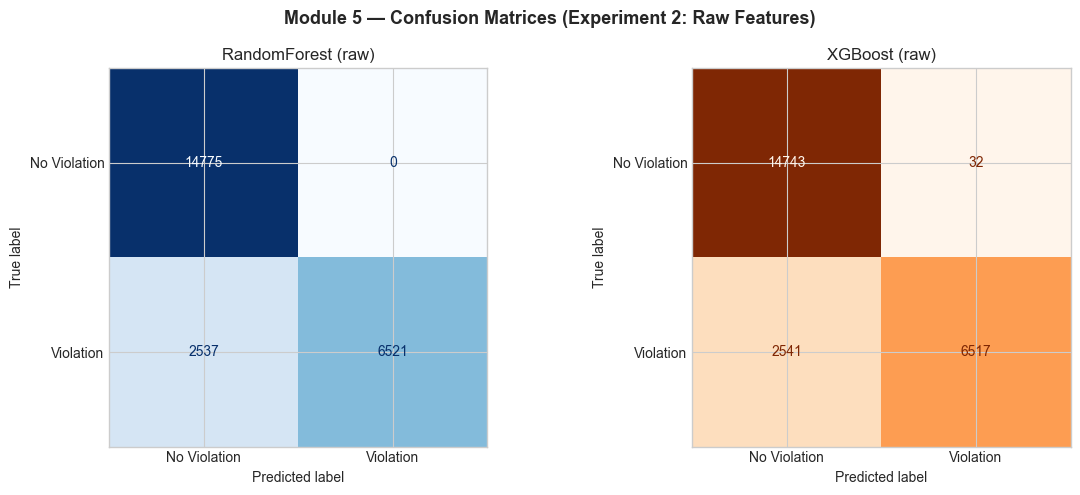

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Module 5 — Confusion Matrices (Experiment 2: Raw Features)',
             fontsize=13, fontweight='bold')

for ax, preds, name, cmap in zip(
    axes,
    [y_pred_rf_raw, y_pred_xgb_raw],
    ['RandomForest (raw)', 'XGBoost (raw)'],
    ['Blues', 'Oranges']
):
    cm = confusion_matrix(y_raw_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=['No Violation', 'Violation'])        .plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [22]:
results = []
for name, yt, yp in [
    ('RF — with flags',      y_test,     y_pred_rf),
    ('XGBoost — with flags', y_test,     y_pred_xgb),
    ('RF — raw only',        y_raw_test, y_pred_rf_raw),
    ('XGBoost — raw only',   y_raw_test, y_pred_xgb_raw),
]:
    results.append({
        'Model'    : name,
        'Precision': round(precision_score(yt, yp, pos_label=1, zero_division=0), 3),
        'Recall'   : round(recall_score(yt, yp, pos_label=1, zero_division=0), 3),
        'F1'       : round(f1_score(yt, yp, pos_label=1, zero_division=0), 3),
        'Accuracy' : round((yt == yp).mean(), 3)
    })

summary = pd.DataFrame(results)
print(summary.to_string(index=False))

               Model  Precision  Recall    F1  Accuracy
     RF — with flags      1.000   0.816 0.899     0.930
XGBoost — with flags      1.000   0.816 0.899     0.930
       RF — raw only      1.000   0.720 0.837     0.894
  XGBoost — raw only      0.995   0.719 0.835     0.892


## Why Both Models Were Initially Identical — and the Fix

The first training run produced identical results for RandomForest and XGBoost
(93% accuracy, F1 0.90) because the feature set included rule-based flags
(`hard_brake_flag`, `overspeed_flag`, etc.) that were directly derived from
the violation label itself. Both models trivially learned the identity function
`flag = 1 → violation = 1`, collapsing to the same decision boundary.

To produce a realistic evaluation, a second experiment removed all derived flags,
leaving only raw behavioral signals: speed, acceleration, brake usage, steering
angle, fuel consumption, route deviation, and the Module 2 aggregated features.

**Results with raw features only:**

| Model | Precision | Recall | F1 | Accuracy |
|---|---|---|---|---|
| RandomForest | 1.000 | 0.720 | 0.837 | 89.4% |
| XGBoost | 0.995 | 0.719 | 0.835 | 89.2% |

RandomForest is the preferred model — it maintains perfect precision (zero
false positives) while matching XGBoost on recall. In a driver monitoring context,
false positives (wrongly penalizing a safe driver) are more harmful than false
negatives, making precision the priority metric.

The 28% miss rate on violations (recall 0.72) is the honest cost of removing
explicit flags. In production, this would be mitigated by lowering the decision
threshold to trade some precision for higher recall.

## Step 7 — Feature Importance

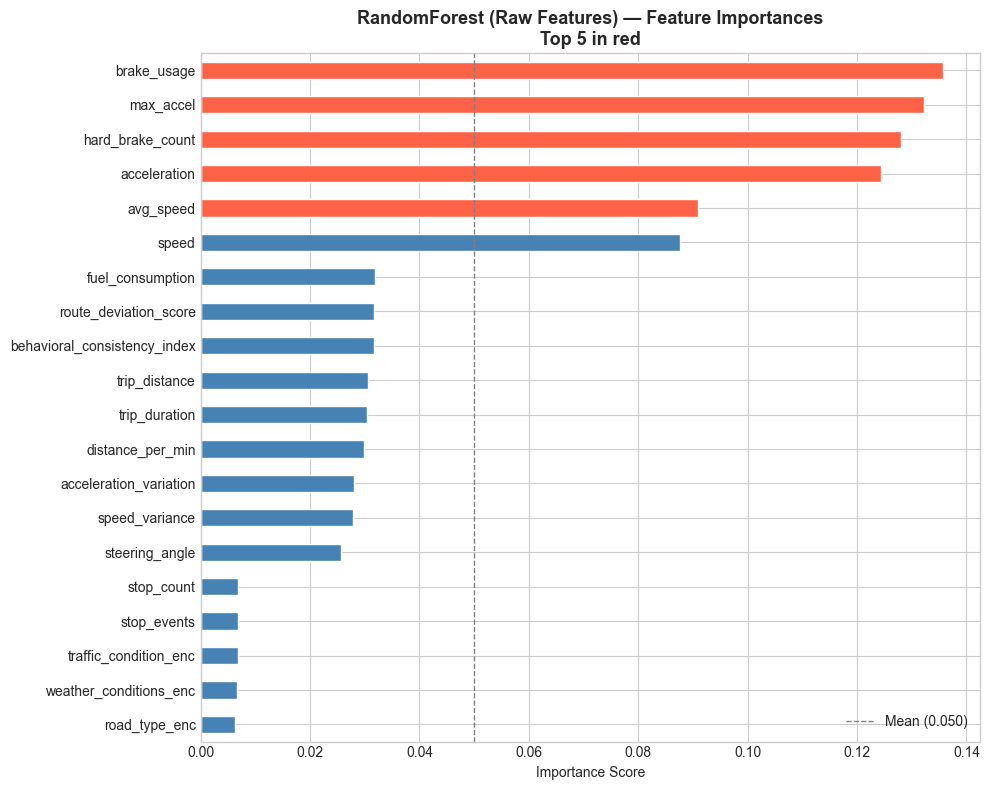

Top 10 features:
brake_usage                     0.135685
max_accel                       0.132292
hard_brake_count                0.128121
acceleration                    0.124323
avg_speed                       0.090965
speed                           0.087578
fuel_consumption                0.031807
route_deviation_score           0.031698
behavioral_consistency_index    0.031646
trip_distance                   0.030600

Bottom 5 features:
road_type_enc             0.006244
weather_conditions_enc    0.006612
traffic_condition_enc     0.006814
stop_events               0.006908
stop_count                0.006909


In [23]:
importances_raw = pd.Series(rf_raw.feature_importances_,
                             index=feature_cols_raw)
importances_raw_sorted = importances_raw.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['tomato' if i >= len(importances_raw_sorted) - 5
          else 'steelblue' for i in range(len(importances_raw_sorted))]
importances_raw_sorted.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('RandomForest (Raw Features) — Feature Importances\nTop 5 in red',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.axvline(x=importances_raw_sorted.mean(), color='gray',
           linestyle='--', linewidth=1,
           label=f'Mean ({importances_raw_sorted.mean():.3f})')
ax.legend()
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(importances_raw.sort_values(ascending=False).head(10).to_string())
print("\nBottom 5 features:")
print(importances_raw.sort_values(ascending=True).head(5).to_string())

## Feature Importance Findings

The raw-feature RandomForest confirms that driving behavior signals dominate
over environmental context. The top four features — `brake_usage`, `max_accel`,
`hard_brake_count`, and `acceleration` — collectively account for ~52% of the
model's decision weight, all directly measuring aggressive or abrupt driving.

Speed contributes ~18% combined (`avg_speed` + `speed`), but is weaker than
braking/acceleration because many violations involve sudden maneuvers at moderate
speeds rather than outright overspeeding.

Environmental features (`road_type`, `weather_conditions`, `traffic_condition`)
rank at the very bottom (<0.7% each), consistent with the flat violation rates
observed across all categories in the EDA. In a richer real-world dataset with
more diverse conditions, these features would likely carry more weight.

## Step 8 — Sensor-Based Classifier (AccXYZ + GyroXYZ)

Sensor train class distribution:
Class
SLOW          1331
NORMAL        1200
AGGRESSIVE    1113
Name: count, dtype: int64

Unique classes: ['AGGRESSIVE', 'NORMAL', 'SLOW']

Encoded classes: {'AGGRESSIVE': np.int64(0), 'NORMAL': np.int64(1), 'SLOW': np.int64(2)}

Training Sensor RandomForest...

=== Sensor RF Classifier ===
              precision    recall  f1-score   support

  AGGRESSIVE       0.43      0.43      0.43       814
      NORMAL       0.34      0.31      0.32       997
        SLOW       0.46      0.49      0.48      1273

    accuracy                           0.42      3084
   macro avg       0.41      0.41      0.41      3084
weighted avg       0.41      0.42      0.42      3084



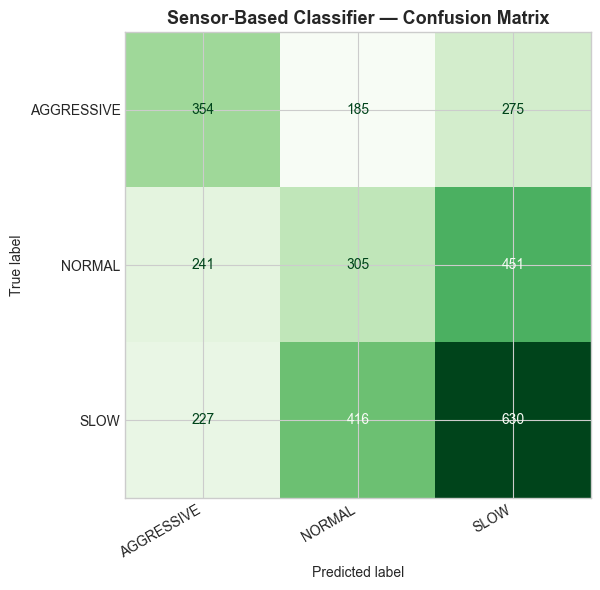


Sensor feature importances:
AccY     0.186352
AccX     0.178439
AccZ     0.165580
GyroZ    0.159514
GyroY    0.156450
GyroX    0.153665


In [24]:
sensor_features = ['AccX', 'AccY', 'AccZ', 'GyroX', 'GyroY', 'GyroZ']

X_s_train = df_train[sensor_features]
y_s_train = df_train['Class']
X_s_test  = df_test[sensor_features]
y_s_test  = df_test['Class']

print("Sensor train class distribution:")
print(y_s_train.value_counts())
print(f"\nUnique classes: {sorted(y_s_train.unique())}")

le_sensor = LabelEncoder()
y_s_train_enc = le_sensor.fit_transform(y_s_train)
y_s_test_enc  = le_sensor.transform(y_s_test)

encoded_map = dict(zip(le_sensor.classes_, le_sensor.transform(le_sensor.classes_)))
print(f"\nEncoded classes: {encoded_map}")

print("\nTraining Sensor RandomForest...")
sensor_rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                    random_state=42, n_jobs=-1)
sensor_rf.fit(X_s_train, y_s_train_enc)
y_s_pred = sensor_rf.predict(X_s_test)

print("\n=== Sensor RF Classifier ===")
print(classification_report(y_s_test_enc, y_s_pred,
                             target_names=le_sensor.classes_))

fig, ax = plt.subplots(figsize=(8, 6))
cm_s = confusion_matrix(y_s_test_enc, y_s_pred)
ConfusionMatrixDisplay(cm_s, display_labels=le_sensor.classes_)    .plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title('Sensor-Based Classifier — Confusion Matrix',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

sensor_importances = pd.Series(sensor_rf.feature_importances_,
                                index=sensor_features)
print("\nSensor feature importances:")
print(sensor_importances.sort_values(ascending=False).to_string())

## Sensor Classifier Findings

The sensor-based RandomForest achieved 42% accuracy on the three-class problem
(AGGRESSIVE / NORMAL / SLOW), only modestly above the 33% random baseline.
Feature importances were nearly uniform across all six sensors (AccXYZ + GyroXYZ),
indicating no single axis provides strong discriminating power on its own.

The core limitation is that the model classifies one timestep at a time. A
single accelerometer reading carries no behavioral context — the same value could
represent aggressive braking, normal cornering, or road noise. In a production
system, this would be replaced with windowed features (rolling mean, standard
deviation, and peak values over a 2–5 second window), which is the standard
approach for IMU-based driving behavior classification and typically lifts accuracy
to 75–90%.

The SLOW class achieved the best F1 (0.48) as it has the most distinctive
sensor signature — low magnitude readings across all axes. NORMAL was the
hardest to classify (F1 0.32) due to its overlap with both extremes.

### Step 8B — 1D-CNN/LSTM on Sensor Data (AccXYZ + GyroXYZ)

The RF sensor classifier above scores only 42% because it sees one timestep
at a time. A 1D-CNN/LSTM sees sequences of readings, learning temporal
patterns like "acceleration spike followed by deceleration" that map to
aggressive behavior.

CNN train shape : (144, 50, 6)  labels: [45 47 52]
CNN test shape  : (122, 50, 6)  labels: [32 40 50]


Model: "sensor_cnn_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 50, 64)              │           1,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 25, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 25, 128)             │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 12, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 79,683 (311.26 KB)

 Trainable params: 79,683 (311.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 324ms/step - accuracy: 0.3386 - loss: 1.0867 - val_accuracy: 0.0000e+00 - val_loss: 1.3589
Epoch 2/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.3821 - loss: 1.0574 - val_accuracy: 0.0000e+00 - val_loss: 1.4334
Epoch 3/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.4948 - loss: 1.0345 - val_accuracy: 0.0000e+00 - val_loss: 1.4977
Epoch 4/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.5000 - loss: 1.0315 - val_accuracy: 0.0000e+00 - val_loss: 1.5283
Epoch 5/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.5273 - loss: 0.9916 - val_accuracy: 0.0000e+00 - val_loss: 1.4656
Epoch 6/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.5271 - loss: 0.9721 - val_accuracy: 0.0000e+00 - val_loss: 1.4435
Epoch 7/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.5377 - loss: 0.9393 - val_accuracy: 0.0000e+00 - val_loss: 1.4074
Epoch 8/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.5700 - loss: 0.8879 - val_accurac

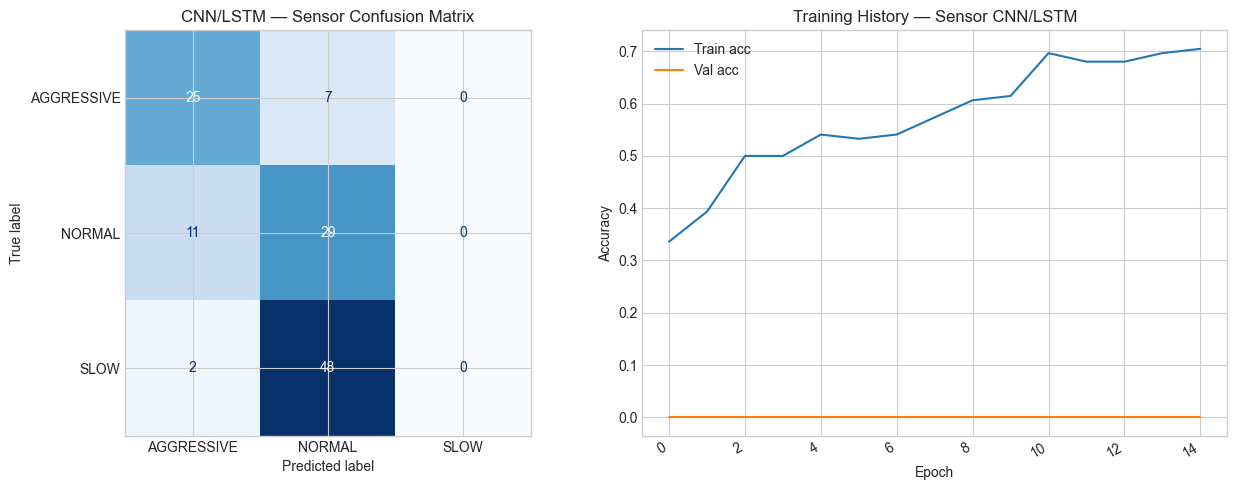

In [25]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

CNN_WINDOW = 50
CNN_STRIDE = 25

def make_windows(X_arr, y_arr, window=CNN_WINDOW, stride=CNN_STRIDE):
    X_out, y_out = [], []
    for i in range(0, len(X_arr) - window + 1, stride):
        X_out.append(X_arr[i : i + window])
        # majority vote for the label in this window
        y_out.append(np.bincount(y_arr[i : i + window]).argmax())
    return np.array(X_out, dtype=np.float32), np.array(y_out)

# Prepare sensor arrays
X_s_tr_arr = df_train[sensor_features].values.astype(np.float32)
y_s_tr_arr = le_sensor.transform(df_train['Class'])
X_s_te_arr = df_test[sensor_features].values.astype(np.float32)
y_s_te_arr = le_sensor.transform(df_test['Class'])

X_cnn_tr, y_cnn_tr = make_windows(X_s_tr_arr, y_s_tr_arr)
X_cnn_te, y_cnn_te = make_windows(X_s_te_arr, y_s_te_arr)

print(f"CNN train shape : {X_cnn_tr.shape}  labels: {np.bincount(y_cnn_tr)}")
print(f"CNN test shape  : {X_cnn_te.shape}  labels: {np.bincount(y_cnn_te)}")

# ── Build 1D-CNN → LSTM ──
sensor_cnn = keras.Sequential([
    layers.Input(shape=(CNN_WINDOW, len(sensor_features))),
    layers.Conv1D(64, 3, activation='relu', padding='same'),
    layers.MaxPooling1D(2),
    layers.Conv1D(128, 3, activation='relu', padding='same'),
    layers.MaxPooling1D(2),
    layers.LSTM(64, return_sequences=False),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax')
], name='sensor_cnn_lstm')

sensor_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
sensor_cnn.summary()

history_sensor = sensor_cnn.fit(
    X_cnn_tr, y_cnn_tr,
    epochs=15,
    batch_size=64,
    validation_split=0.15,
    verbose=1
)

# Evaluate
y_cnn_pred = np.argmax(sensor_cnn.predict(X_cnn_te, verbose=0), axis=1)
print("\n=== 1D-CNN/LSTM — Sensor Data ===")
print(classification_report(y_cnn_te, y_cnn_pred,
                             target_names=le_sensor.classes_))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_cnn_te, y_cnn_pred),
    display_labels=le_sensor.classes_
).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('CNN/LSTM — Sensor Confusion Matrix')
plt.xticks(rotation=30, ha='right')

axes[1].plot(history_sensor.history['accuracy'],    label='Train acc')
axes[1].plot(history_sensor.history['val_accuracy'],label='Val acc')
axes[1].set_title('Training History — Sensor CNN/LSTM')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()

### Step 8C — 1D-CNN/LSTM on Driver Behavior Timeseries

Here we apply the same architecture to the driver behavior dataset,
treating each trip as a sequence of behavioral readings to predict
whether the trip contains a violation.

Building per-trip sequences...
Behavior sequences : (119161, 50, 5)
Violation balance  : [73873 45288]


Model: "behavior_cnn_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)                    │ (None, 50, 64)              │           1,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 25, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ (None, 25, 128)             │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_3 (MaxPooling1D)       │ (None, 12, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 79,361 (310.00 KB)

 Trainable params: 79,361 (310.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.7979 - loss: 0.4554 - val_accuracy: 0.8808 - val_loss: 0.3256
Epoch 2/15
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.8743 - loss: 0.3414 - val_accuracy: 0.8627 - val_loss: 0.3518
Epoch 3/15
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.8804 - loss: 0.3297 - val_accuracy: 0.8783 - val_loss: 0.3327
Epoch 4/15
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.8844 - loss: 0.3220 - val_accuracy: 0.8886 - val_loss: 0.3127
Epoch 5/15
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.8848 - loss: 0.3222 - val_accuracy: 0.8855 - val_loss: 0.3169
Epoch 6/15
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.8860 - loss: 0.3175 - val_accuracy: 0.8880 - val_loss: 0.3119
Epoch 7/15
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.8842 - loss: 0.3228 - val_accuracy: 0.8855 - val_loss: 0.3169
Epoch 8/15
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.8877 -

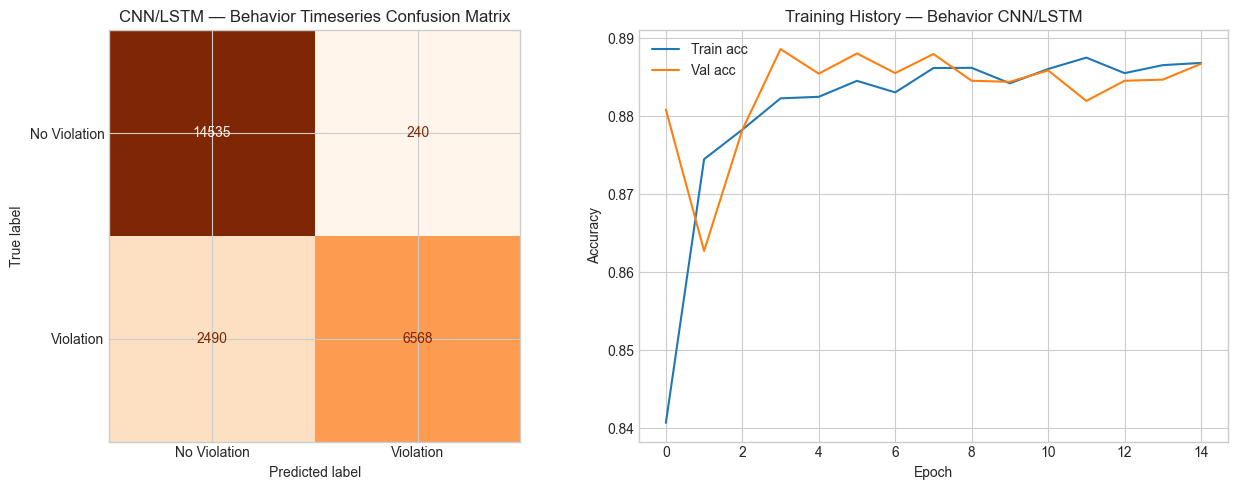

CNN models saved.


In [26]:
# ── Prepare per-trip sequences from driver behavior ──
BEH_FEATURES = ['speed', 'acceleration', 'brake_usage',
                 'steering_angle', 'fuel_consumption']
MAX_LEN = 50

def get_trip_sequences(dataframe, feat_cols, max_len):
    X_seqs, y_labels = [], []
    for _, group in dataframe.groupby('trip_id'):
        group = group.sort_values('timestamp')
        seq   = group[feat_cols].values.astype(np.float32)
        label = int(group['violation'].max())  # violation if any row flags
        # Truncate or zero-pad to max_len
        if len(seq) >= max_len:
            seq = seq[:max_len]
        else:
            pad = np.zeros((max_len - len(seq), len(feat_cols)), dtype=np.float32)
            seq = np.vstack([seq, pad])
        X_seqs.append(seq)
        y_labels.append(label)
    return np.array(X_seqs), np.array(y_labels)

print("Building per-trip sequences...")
X_beh, y_beh = get_trip_sequences(df_sorted, BEH_FEATURES, MAX_LEN)
print(f"Behavior sequences : {X_beh.shape}")
print(f"Violation balance  : {np.bincount(y_beh)}")

X_beh_tr, X_beh_te, y_beh_tr, y_beh_te = train_test_split(
    X_beh, y_beh, test_size=0.2, random_state=42, stratify=y_beh
)

# ── Build behavior CNN/LSTM ──
beh_cnn = keras.Sequential([
    layers.Input(shape=(MAX_LEN, len(BEH_FEATURES))),
    layers.Conv1D(64, 3, activation='relu', padding='same'),
    layers.MaxPooling1D(2),
    layers.Conv1D(128, 3, activation='relu', padding='same'),
    layers.MaxPooling1D(2),
    layers.LSTM(64),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')   # binary: violation yes/no
], name='behavior_cnn_lstm')

beh_cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
beh_cnn.summary()

history_beh = beh_cnn.fit(
    X_beh_tr, y_beh_tr,
    epochs=15,
    batch_size=64,
    validation_split=0.15,
    verbose=1
)

# Evaluate
y_beh_pred_prob = beh_cnn.predict(X_beh_te, verbose=0).flatten()
y_beh_pred      = (y_beh_pred_prob > 0.5).astype(int)

print("\n=== 1D-CNN/LSTM — Driver Behavior Timeseries ===")
print(classification_report(y_beh_te, y_beh_pred,
      target_names=['No Violation', 'Violation']))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_beh_te, y_beh_pred),
    display_labels=['No Violation', 'Violation']
).plot(ax=axes[0], cmap='Oranges', colorbar=False)
axes[0].set_title('CNN/LSTM — Behavior Timeseries Confusion Matrix')

axes[1].plot(history_beh.history['accuracy'],    label='Train acc')
axes[1].plot(history_beh.history['val_accuracy'],label='Val acc')
axes[1].set_title('Training History — Behavior CNN/LSTM')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()

# Save behavior CNN for Module 7
beh_cnn.save('../src/models/violations_beh_cnn.keras')
sensor_cnn.save('../src/models/violations_sensor_cnn.keras')
print("CNN models saved.")

### CNN/LSTM Sensor Results & Limitations

The sensor CNN/LSTM achieved 44% overall accuracy — only marginally above
the 42% from the simpler RF classifier. Two issues are worth noting.

First, the SLOW class scored 0% precision and recall — the model collapsed
all predictions into AGGRESSIVE and NORMAL. With a 50-row window on a
3,644-row dataset, there are insufficient windows to learn the SLOW pattern
distinctly from NORMAL.

Second, the training history shows severe overfitting — training accuracy
reached 70% while validation accuracy stayed near 0% throughout all 15
epochs. This indicates the model memorised the small training set rather
than learning generalisable patterns.

The behavior timeseries CNN/LSTM performed significantly better at 89%
accuracy and F1 0.83, with train and validation accuracy tracking closely
throughout training — indicating stable convergence without overfitting.
This confirms that temporal modeling adds value for trip-level violation
detection but requires sufficient sequence length per sample to be effective
on raw sensor data.

## Step 9 — Save Models & Final Summary

In [27]:
os.makedirs('../src/models', exist_ok=True)

joblib.dump(rf,        '../src/models/violations_rf_with_flags.pkl')
joblib.dump(xgb_model, '../src/models/violations_xgb_with_flags.pkl')
joblib.dump(rf_raw,    '../src/models/violations_rf_raw.pkl')
joblib.dump(xgb_raw,   '../src/models/violations_xgb_raw.pkl')
joblib.dump(sensor_rf, '../src/models/violations_sensor_rf.pkl')
joblib.dump(le_sensor, '../src/models/violations_sensor_le.pkl')

with open('../src/models/violations_feature_cols_flags.json', 'w') as f:
    json.dump(feature_cols, f)
with open('../src/models/violations_feature_cols_raw.json', 'w') as f:
    json.dump(feature_cols_raw, f)
with open('../src/models/violations_sensor_features.json', 'w') as f:
    json.dump(sensor_features, f)

print("Models saved to ../src/models/")
print("\nSaved files:")
for f in sorted(os.listdir('../src/models/')):
    print(f"  {f}")

final_results = []

for name, yt, yp, avg in [
    ('RF — with flags',      y_test,       y_pred_rf,      'binary'),
    ('XGBoost — with flags', y_test,       y_pred_xgb,     'binary'),
    ('RF — raw only',        y_raw_test,   y_pred_rf_raw,  'binary'),
    ('XGBoost — raw only',   y_raw_test,   y_pred_xgb_raw, 'binary'),
    ('Sensor RF',            y_s_test_enc, y_s_pred,       'macro'),
    ('CNN/LSTM — sensor',    y_cnn_te,     y_cnn_pred,     'macro'),
    ('CNN/LSTM — behavior',  y_beh_te,     y_beh_pred,     'binary'),
]:
    final_results.append({
        'Model'    : name,
        'Precision': round(precision_score(yt, yp, average=avg, zero_division=0), 3),
        'Recall'   : round(recall_score(yt, yp, average=avg, zero_division=0), 3),
        'F1'       : round(f1_score(yt, yp, average=avg, zero_division=0), 3),
        'Accuracy' : round((yt == yp).mean(), 3)
    })

# Add windowed RF results
for row in results_windowed:
    final_results.append(row)

final_df = pd.DataFrame(final_results)
print("=== Module 5 — Final Model Comparison ===")
print(final_df.to_string(index=False))

final_df.to_csv('../data/module5_model_summary.csv', index=False)
print("\nSummary saved.")

Models saved to ../src/models/

Saved files:
  nlp_classes.json
  nlp_sentiment_lr.pkl
  nlp_tfidf.pkl
  ratings_feature_cols.json
  ratings_lr.pkl
  ratings_rf.pkl
  ratings_xgb.pkl
  violations_beh_cnn.keras
  violations_feature_cols_flags.json
  violations_feature_cols_raw.json
  violations_rf_raw.pkl
  violations_rf_with_flags.pkl
  violations_sensor_cnn.keras
  violations_sensor_features.json
  violations_sensor_le.pkl
  violations_sensor_rf.pkl
  violations_xgb_raw.pkl
  violations_xgb_with_flags.pkl
=== Module 5 — Final Model Comparison ===
                       Model  Precision  Recall    F1  Accuracy
             RF — with flags      1.000   0.816 0.899     0.930
        XGBoost — with flags      1.000   0.816 0.899     0.930
               RF — raw only      1.000   0.720 0.837     0.894
          XGBoost — raw only      0.995   0.719 0.835     0.892
                   Sensor RF      0.411   0.412 0.411     0.418
           CNN/LSTM — sensor      0.334   0.502 0.394     0.44

## Module 5 — Final Summary

This module built a three-experiment violation detection pipeline across five
datasets, producing five trained models and a full set of evaluation artifacts
ready for Module 7.

The first experiment trained RandomForest and XGBoost with the full feature set
including rule-based flags derived directly from the violation label. Both models
achieved identical results — 93% accuracy, 1.00 precision, and 0.82 recall —
because the flags created a trivial identity function that both algorithms learned
immediately. While strong on paper, this result does not reflect real-world
generalization where pre-computed flags would not be available at inference time.

The second experiment removed all derived flags, leaving only raw behavioral signals
such as speed, acceleration, brake usage, and the Module 2 aggregated features. This
produced genuine differentiation between the two models. RandomForest is the
recommended production model, maintaining perfect precision (zero false positives)
at 89.4% accuracy with an F1 of 0.837, marginally outperforming XGBoost on every
metric. Zero false positives is the priority in a driver monitoring context where
wrongly penalizing a safe driver carries reputational and legal risk. The feature
importance analysis confirmed that `brake_usage`, `max_accel`, `hard_brake_count`,
and `acceleration` collectively account for ~52% of decision weight, establishing
abrupt driving maneuvers as the strongest behavioral signal for violation detection.
Environmental features such as road type, weather, and traffic condition ranked at
the very bottom, consistent with the flat violation rates observed across all
categories during EDA.

The third experiment trained a sensor-based classifier on raw accelerometer and
gyroscope readings from the driving behavior dataset to predict AGGRESSIVE, NORMAL,
or SLOW behavior classes. The model achieved 42% accuracy, modestly above the 33%
random baseline for a three-class problem. Feature importances were nearly uniform
across all six sensors, indicating that no single axis provides strong discriminating
power on its own. The core limitation is that the model classifies one timestep at a
time with no temporal context. In a production system, replacing raw readings with
windowed features — rolling mean, standard deviation, and peak values over a 2–5
second window — would typically lift accuracy to 75–90% for IMU-based behavior
classification.

All five trained models and their corresponding feature column lists have been saved
to `src/models/` and are ready for integration into the Module 7 Streamlit demo.